# LLM Distillation (Phi-3 → TinyLlama, SQuAD)

P1 baseline → P2 QLoRA → выбор teacher → P3 дистилляция → отчёт.

Запускать на Kaggle с GPU T4 x2 (или L4).

In [1]:
import importlib, os, sys, subprocess

def _install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

def _missing(module):
    try:
        importlib.import_module(module)
        return False
    except ImportError:
        return True

if os.path.exists("/kaggle/working"):
    # на Kaggle torch уже есть с поддержкой GPU — доставляем только то чего не хватает
    needed = {"evaluate": "evaluate", "peft": "peft", "bitsandbytes": "bitsandbytes"}
    missing = [pkg for pkg, mod in needed.items() if _missing(mod)]
    if missing:
        _install(*missing)
else:
    # Colab / локально — ставим всё что не установлено
    all_pkgs = {
        "torch": "torch", "transformers": "transformers", "datasets": "datasets",
        "evaluate": "evaluate", "peft": "peft", "bitsandbytes": "bitsandbytes",
        "accelerate": "accelerate", "pandas": "pandas", "numpy": "numpy",
        "scikit-learn": "sklearn"}
    missing = [pkg for pkg, mod in all_pkgs.items() if _missing(mod)]
    if missing:
        print("устанавливаем:", missing)
        _install(*missing)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
from __future__ import annotations

import gc, json, os, random, re, shutil, time, zipfile
from dataclasses import dataclass, asdict
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import evaluate
import torch
import torch.nn.functional as F
from datasets import load_dataset
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
def _detect_runtime():
    if os.path.exists("/kaggle/working"):
        return "kaggle"
    if os.path.exists("/content"):
        return "colab"
    return "local"

RUNTIME = _detect_runtime()
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if RUNTIME == "kaggle":
    ARTIFACTS_DIR = Path("/kaggle/working/artifacts")
elif RUNTIME == "colab":
    ARTIFACTS_DIR = Path("/content/artifacts")
else:
    ARTIFACTS_DIR = BASE_DIR / "artifacts"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
print("runtime:", RUNTIME)
print("artifacts:", ARTIFACTS_DIR)

runtime: kaggle
artifacts: /kaggle/working/artifacts


In [4]:
# FORCE_RERUN=True — пересчитать все стадии заново, даже если файлы уже есть
FORCE_RERUN = os.getenv("FORCE_RERUN_STAGES", "1") == "1"

In [5]:
SEED = int(os.getenv("GLOBAL_SEED", "42"))

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED) 

In [6]:
TEACHER_MODEL = "microsoft/Phi-3-mini-4k-instruct"
STUDENT_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

DATASET_NAME = "rajpurkar/squad"
TRAIN_SPLIT  = "train"
TEST_SPLIT   = "validation"

In [7]:
# гиперпараметры обучения
LR             = 2e-5
TRAIN_BS       = 1
DISTILL_BS     = 1
TEACHER_EPOCHS = 1
STUDENT_EPOCHS = 3   # больше эпох — с early stopping не переобучится

# параметры дистилляции
DISTILL_TEMP = 2.0
ALPHA_CE     = 0.5   # вес CE-лосса студента
BETA_KL      = 0.5   # вес KL-дивергенции с teacher

# если QLoRA дала прирост F1 меньше порога — берём базовый teacher
DELTA_THRESHOLD = 0.01

N_TRAIN = 2056
N_TEST  = 256
MAX_LEN = 320
MAX_NEW = 40


In [8]:
# 4-bit квантизация через bitsandbytes
QUANT_CFG = None
if torch.cuda.is_available():
    QUANT_CFG = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16)

In [9]:
def free_gpu(*objs):
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def load_model(name, quantized=False):
    free_gpu()
    kw = {"low_cpu_mem_usage": True}
    if not torch.cuda.is_available():
        return AutoModelForCausalLM.from_pretrained(name, **kw)
    if quantized and QUANT_CFG:
        return AutoModelForCausalLM.from_pretrained(
            name, quantization_config=QUANT_CFG,
            device_map="auto", max_memory={0: "10GiB", "cpu": "64GiB"}, **kw)
    return AutoModelForCausalLM.from_pretrained(
        name, torch_dtype=torch.float16,
        device_map="auto", max_memory={0: "10GiB", "cpu": "64GiB"}, **kw)

def save_json(path, data):
    Path(path).write_text(json.dumps(data, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def clean_artifacts():
    if not FORCE_RERUN:
        return
    for f in ["p1_baseline_metrics.json", "p2_qlora_metrics.json", "teacher_choice.json",
              "p3_student_metrics.json", "final_report.md", "sql_extension_metrics.json",
              "sql_predictions.jsonl", "sql_report.md", "sql_run_manifest.json", "run_manifest.json"]:
        p = ARTIFACTS_DIR / f
        if p.exists():
            p.unlink()
    for d in ["teacher_qlora_adapter", "student_distilled"]:
        p = ARTIFACTS_DIR / d
        if p.exists():
            shutil.rmtree(p)

def save_manifest(extra=None):
    data = {
        "teacher": TEACHER_MODEL, "student": STUDENT_MODEL,
        "dataset": DATASET_NAME, "n_train": N_TRAIN, "n_test": N_TEST,
        "seed": SEED, "torch": torch.__version__,
        "cuda": torch.cuda.is_available(),
        "ts": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),}
    if torch.cuda.is_available():
        data["gpu"] = torch.cuda.get_device_name(0)
    if extra:
        data.update(extra)
    save_json(ARTIFACTS_DIR / "run_manifest.json", data)

In [10]:
def make_prompt(context, question):
    return (
        "You are a question-answering assistant.\n"
        "Answer with a short exact span from context only.\n\n"
        f"Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"
    )

def parse_answer(text):
    # берём только то что идёт после последнего ответа
    if "Answer:" in text:
        text = text.split("Answer:", maxsplit=1)[-1].strip()
    return text.split("\n", maxsplit=1)[0].strip()

@dataclass
class StageMetrics:
    split: str
    model_name: str
    sample_count: int
    exact_match: float
    f1: float
    avg_latency_sec: float
    throughput_samples_per_sec: float
    max_memory_gb: float

    def to_dict(self):
        return asdict(self)

def metrics_from_saved(payload):
    return StageMetrics(**payload["metrics"])

def run_eval(model, tokenizer, dataset, split_name, tag=None):
    squad_metric = evaluate.load("squad")
    model.eval()
    dev = next(model.parameters()).device
    on_gpu = torch.cuda.is_available() and str(dev).startswith("cuda")
    if on_gpu:
        torch.cuda.reset_peak_memory_stats(dev)

    preds, refs, times, details = [], [], [], []
    for row in dataset:
        prompt = make_prompt(row["context"], row["question"])
        enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN)
        enc = {k: v.to(dev) for k, v in enc.items()}

        t0 = time.perf_counter()
        with torch.no_grad():
            out = model.generate(
                **enc, max_new_tokens=MAX_NEW, do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id)
        times.append(time.perf_counter() - t0)

        pred    = parse_answer(tokenizer.decode(out[0], skip_special_tokens=True))
        answers = row["answers"].get("text", [])
        starts  = row["answers"].get("answer_start", [0] * len(answers))
        if len(starts) != len(answers):
            starts = [0] * len(answers)

        rid = str(row["id"])
        preds.append({"id": rid, "prediction_text": pred})
        refs.append({"id": rid, "answers": {"text": answers, "answer_start": starts}})
        details.append({"id": rid, "question": row["question"], "gold": answers, "pred": pred})

    scores = squad_metric.compute(predictions=preds, references=refs)

    if tag:
        out_path = ARTIFACTS_DIR / f"{tag}_predictions.jsonl"
        out_path.write_text(
            "\n".join(json.dumps(x, ensure_ascii=False) for x in details) + "\n",
            encoding="utf-8")

    avg_t    = sum(times) / max(1, len(times))
    tput     = len(times) / max(1e-9, sum(times))
    peak_mem = torch.cuda.max_memory_allocated(dev) / 1024**3 if on_gpu else 0.0

    return StageMetrics(
        split=split_name,
        model_name=str(getattr(model, "name_or_path", "model")),
        sample_count=len(preds),
        exact_match=float(scores["exact_match"]),
        f1=float(scores["f1"]),
        avg_latency_sec=float(avg_t),
        throughput_samples_per_sec=float(tput),
        max_memory_gb=float(peak_mem))

In [11]:
clean_artifacts()
print(f"teacher  : {TEACHER_MODEL}")
print(f"student  : {STUDENT_MODEL}")
print(f"выборка  : train={N_TRAIN}  test={N_TEST}")
print(f"артефакты: {ARTIFACTS_DIR}")

teacher  : microsoft/Phi-3-mini-4k-instruct
student  : TinyLlama/TinyLlama-1.1B-Chat-v1.0
выборка  : train=2056  test=256
артефакты: /kaggle/working/artifacts


In [12]:
# загружаем датасет и токенизируем под teacher и student отдельно -> разные словари = разные токенизаторы
train_raw = load_dataset(DATASET_NAME, split=TRAIN_SPLIT,
    download_mode="reuse_cache_if_exists").shuffle(seed=SEED).select(range(N_TRAIN))

test_raw  = load_dataset(DATASET_NAME, split=TEST_SPLIT,
    download_mode="reuse_cache_if_exists").shuffle(seed=SEED).select(range(N_TEST))

teacher_tok = AutoTokenizer.from_pretrained(TEACHER_MODEL, use_fast=True)
student_tok = AutoTokenizer.from_pretrained(STUDENT_MODEL, use_fast=True)
if teacher_tok.pad_token is None:
    teacher_tok.pad_token = teacher_tok.eos_token
if student_tok.pad_token is None:
    student_tok.pad_token = student_tok.eos_token

def _to_train_text(row):
    ans = row.get("answers", {}).get("text", [""])[0] or ""
    return make_prompt(row["context"], row["question"]) + " " + ans

def _tokenize(tok, batch):
    out = tok(batch["text"], truncation=True, padding="max_length", max_length=MAX_LEN)
    out["labels"] = out["input_ids"].copy()
    return out

split    = train_raw.train_test_split(test_size=0.15, seed=SEED)
train_ds = split["train"]
val_ds   = split["test"]

text_train = train_ds.map(lambda x: {"text": _to_train_text(x)})
text_train = text_train.remove_columns([c for c in text_train.column_names if c != "text"])

text_val = val_ds.map(lambda x: {"text": _to_train_text(x)})
text_val = text_val.remove_columns([c for c in text_val.column_names if c != "text"])

# teacher токенизируем от полного train_raw — ему val split не нужен
text_full = train_raw.map(lambda x: {"text": _to_train_text(x)})
text_full = text_full.remove_columns([c for c in text_full.column_names if c != "text"])

tok_train_teacher = text_full.map(lambda b: _tokenize(teacher_tok, b), batched=True, remove_columns=["text"])
tok_train_student = text_train.map(lambda b: _tokenize(student_tok, b), batched=True, remove_columns=["text"])
tok_val_student   = text_val.map(lambda b: _tokenize(student_tok, b),  batched=True, remove_columns=["text"])

tok_train_teacher.set_format(type="torch")
tok_train_student.set_format(type="torch")
tok_val_student.set_format(type="torch")

print(f"train teacher: {len(tok_train_teacher)}")
print(f"train student: {len(tok_train_student)}  val student: {len(tok_val_student)}")
print(f"test: {len(test_raw)}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/2056 [00:00<?, ? examples/s]

Map:   0%|          | 0/2056 [00:00<?, ? examples/s]

Map:   0%|          | 0/1747 [00:00<?, ? examples/s]

Map:   0%|          | 0/309 [00:00<?, ? examples/s]

train teacher: 2056
train student: 1747  val student: 309
test: 256


In [13]:
from datasets import load_dataset

test_full = load_dataset("rajpurkar/squad", split="validation")
test_shuffled = test_full.shuffle(seed=42).select(range(128))

from collections import Counter
titles = Counter(test_shuffled["title"])
print(f"уникальных топиков: {len(titles)}")
for title, n in titles.most_common(10):
    print(f"  {title}: {n}")

уникальных топиков: 42
  Super_Bowl_50: 13
  American_Broadcasting_Company: 6
  Newcastle_upon_Tyne: 5
  Immune_system: 5
  Huguenot: 5
  Southern_California: 4
  Economic_inequality: 4
  Nikola_Tesla: 4
  Teacher: 4
  Apollo_program: 4


In [14]:
# P1 — смотрим на базового teacher без дообучения

p1_path = ARTIFACTS_DIR / "p1_baseline_metrics.json"

if p1_path.exists() and not FORCE_RERUN:
    p1 = metrics_from_saved(load_json(p1_path))
else:
    base = load_model(TEACHER_MODEL, quantized=True)
    p1   = run_eval(base, teacher_tok, test_raw, TEST_SPLIT, tag="p1")
    save_json(p1_path, {
        "stage": "P1_baseline_teacher",
        "teacher_model": TEACHER_MODEL,
        "dataset": DATASET_NAME,
        "metrics": p1.to_dict(),})
    free_gpu(base)

load_json(p1_path)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

{'stage': 'P1_baseline_teacher',
 'teacher_model': 'microsoft/Phi-3-mini-4k-instruct',
 'dataset': 'rajpurkar/squad',
 'metrics': {'split': 'validation',
  'model_name': 'microsoft/Phi-3-mini-4k-instruct',
  'sample_count': 256,
  'exact_match': 14.453125,
  'f1': 43.08573953971438,
  'avg_latency_sec': 2.9672956995078144,
  'throughput_samples_per_sec': 0.33700719485620195,
  'max_memory_gb': 2.430558681488037}}

In [15]:
# P2 — дообучаем teacher через QLoRA (1 эпоха)

p2_path     = ARTIFACTS_DIR / "p2_qlora_metrics.json"
adapter_dir = ARTIFACTS_DIR / "teacher_qlora_adapter"

if p2_path.exists() and adapter_dir.exists() and not FORCE_RERUN:
    p2 = metrics_from_saved(load_json(p2_path))
else:
    teacher = load_model(TEACHER_MODEL, quantized=True)
    lora_cfg = LoraConfig(
        r=16, lora_alpha=32, lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        bias="none", task_type="CAUSAL_LM")
    if QUANT_CFG:
        teacher = prepare_model_for_kbit_training(teacher)
    teacher = get_peft_model(teacher, lora_cfg)

    opt    = torch.optim.AdamW(teacher.parameters(), lr=LR)
    loader = DataLoader(tok_train_teacher, batch_size=TRAIN_BS, shuffle=True)
    teacher.train()

    for epoch in range(TEACHER_EPOCHS):
        for batch in loader:
            batch = {k: v.to(teacher.device) for k, v in batch.items()}
            loss  = teacher(**batch).loss
            opt.zero_grad()
            loss.backward()
            opt.step()
        print(f"эпоха {epoch+1} teacher готова, loss={loss.item():.4f}")

    adapter_dir.mkdir(parents=True, exist_ok=True)
    teacher.save_pretrained(adapter_dir)

    p2 = run_eval(teacher, teacher_tok, test_raw, TEST_SPLIT, tag="p2")
    save_json(p2_path, {
        "stage": "P2_teacher_qlora",
        "teacher_model": TEACHER_MODEL,
        "dataset": DATASET_NAME,
        "metrics": p2.to_dict(),})
    free_gpu(teacher)

load_json(p2_path)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


эпоха 1 teacher готова, loss=6.6514


{'stage': 'P2_teacher_qlora',
 'teacher_model': 'microsoft/Phi-3-mini-4k-instruct',
 'dataset': 'rajpurkar/squad',
 'metrics': {'split': 'validation',
  'model_name': 'microsoft/Phi-3-mini-4k-instruct',
  'sample_count': 256,
  'exact_match': 37.109375,
  'f1': 58.575840042722746,
  'avg_latency_sec': 2.2482535135586232,
  'throughput_samples_per_sec': 0.4447896974114636,
  'max_memory_gb': 5.093602180480957}}

In [16]:
# выбираем какого teacher использовать для дистилляции
# если QLoRA дала заметный прирост F1 — берём его, иначе базовый

choice_path = ARTIFACTS_DIR / "teacher_choice.json"

if choice_path.exists() and not FORCE_RERUN:
    _c          = load_json(choice_path)
    teacher_src = _c["choice"]
    rationale   = _c["rationale"]
else:
    delta       = float(p2.f1) - float(p1.f1)
    teacher_src = "qlora" if delta >= DELTA_THRESHOLD else "base"
    rationale   = f"delta_f1={delta:.4f}, threshold={DELTA_THRESHOLD:.4f}"
    save_json(choice_path, {
        "choice": teacher_src, "metric": "f1",
        "p1_f1": float(p1.f1), "p2_f1": float(p2.f1),
        "delta": float(delta), "threshold": DELTA_THRESHOLD,
        "rationale": rationale,})

print(f"teacher для дистилляции: {teacher_src}  ({rationale})")
load_json(choice_path)

teacher для дистилляции: qlora  (delta_f1=15.4901, threshold=0.0100)


{'choice': 'qlora',
 'metric': 'f1',
 'p1_f1': 43.08573953971438,
 'p2_f1': 58.575840042722746,
 'delta': 15.490100503008364,
 'threshold': 0.01,
 'rationale': 'delta_f1=15.4901, threshold=0.0100'}

In [17]:
# P3 — дистилляция студента от выбранного teacher

p3_path     = ARTIFACTS_DIR / "p3_student_metrics.json"
student_dir = ARTIFACTS_DIR / "student_distilled"

if p3_path.exists() and not FORCE_RERUN:
    p3 = metrics_from_saved(load_json(p3_path))
else:
    # студент тоже с LoRA — иначе не влезет в память
    student = load_model(STUDENT_MODEL, quantized=True)
    if QUANT_CFG:
        student = prepare_model_for_kbit_training(student)
    student = get_peft_model(student, LoraConfig(
        r=16, lora_alpha=32, lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        bias="none", task_type="CAUSAL_LM"))

    # загружаем teacher (с адаптером или без)
    teacher = load_model(TEACHER_MODEL, quantized=True)
    if teacher_src == "qlora" and adapter_dir.exists():
        teacher = PeftModel.from_pretrained(teacher, adapter_dir)
    teacher.eval()

    t_vocab   = int(teacher.config.vocab_size)
    s_vocab   = int(student.config.vocab_size)
    min_vocab = min(t_vocab, s_vocab)  # у Phi-3 и TinyLlama разные словари

    t_dev = next(teacher.parameters()).device
    s_dev = next(student.parameters()).device

    trainable  = [p for p in student.parameters() if p.requires_grad]
    opt        = torch.optim.AdamW(trainable, lr=LR)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=len(DataLoader(tok_train_student, batch_size=DISTILL_BS)) * STUDENT_EPOCHS)
    loader     = DataLoader(tok_train_student, batch_size=DISTILL_BS, shuffle=True)
    val_loader = DataLoader(tok_val_student,   batch_size=DISTILL_BS, shuffle=False)

    def _distill_loss(student, batch, teacher_logits):
        """считает общий лосс дистилляции для одного батча"""
        labels = batch["labels"].clone()
        labels[labels >= s_vocab] = -100
        s_out = student(
            input_ids=batch["input_ids"].clamp(max=s_vocab - 1),
            attention_mask=batch["attention_mask"],
            labels=labels,
        )
        ce_loss = s_out.loss.float()
        # KL только по общей части словаря
        t_log = (teacher_logits[..., :min_vocab] / DISTILL_TEMP).float().to(s_dev)
        s_log = (s_out.logits[..., :min_vocab] / DISTILL_TEMP).float()
        kl_loss = (
            F.kl_div(F.log_softmax(s_log, dim=-1), F.softmax(t_log, dim=-1), reduction="sum")
            / (s_log.shape[0] * s_log.shape[1])
            * DISTILL_TEMP ** 2)
        return ALPHA_CE * ce_loss + BETA_KL * kl_loss

    epoch_losses = []
    best_val     = float("inf")
    patience     = 2
    no_improve   = 0

    for epoch in range(STUDENT_EPOCHS):
        # --- train ---
        total_train = 0.0
        student.train()
        for batch in loader:
            batch = {k: v.to(s_dev) for k, v in batch.items()}
            with torch.no_grad():
                t_logits = teacher(
                    input_ids=batch["input_ids"].to(t_dev),
                    attention_mask=batch["attention_mask"].to(t_dev),
                ).logits
            loss = _distill_loss(student, batch, t_logits)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            opt.step()
            scheduler.step()
            total_train += float(loss.item())

        # --- validation ---
        total_val = 0.0
        student.eval()
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(s_dev) for k, v in batch.items()}
                t_logits = teacher(
                    input_ids=batch["input_ids"].to(t_dev),
                    attention_mask=batch["attention_mask"].to(t_dev),
                ).logits
                total_val += float(_distill_loss(student, batch, t_logits).item())

        avg_train = total_train / max(1, len(loader))
        avg_val   = total_val   / max(1, len(val_loader))
        cur_lr    = scheduler.get_last_lr()[0]
        epoch_losses.append({"train": avg_train, "val": avg_val, "lr": cur_lr})
        print(f"эпоха {epoch+1}  train={avg_train:.4f}  val={avg_val:.4f}  lr={cur_lr:.2e}")

        # early stopping
        if avg_val < best_val - 0.001:
            best_val   = avg_val
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"val loss не улучшается {patience} эпохи подряд — стопаем")
                break

    student_dir.mkdir(parents=True, exist_ok=True)
    student.save_pretrained(student_dir)
    student_tok.save_pretrained(student_dir)

    student.eval()
    p3 = run_eval(student, student_tok, test_raw, TEST_SPLIT, tag="p3")
    save_json(p3_path, {
        "stage": "P3_student_distilled",
        "student_model": STUDENT_MODEL,
        "teacher_source": "qlora_adapter" if teacher_src == "qlora" else "base_teacher",
        "dataset": DATASET_NAME,
        "train_loss_per_epoch": epoch_losses,
        "metrics": p3.to_dict(),})
    free_gpu(teacher, student)

load_json(p3_path)

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

эпоха 1  train=1.5581  val=1.3642  lr=1.50e-05
эпоха 2  train=1.3554  val=1.3454  lr=5.00e-06
эпоха 3  train=1.3411  val=1.3423  lr=0.00e+00


{'stage': 'P3_student_distilled',
 'student_model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
 'teacher_source': 'qlora_adapter',
 'dataset': 'rajpurkar/squad',
 'train_loss_per_epoch': [{'train': 1.5580916000081255,
   'val': 1.3642194112913508,
   'lr': 1.5000000000000031e-05},
  {'train': 1.3554499589789575,
   'val': 1.3454135515543248,
   'lr': 5.000000000000005e-06},
  {'train': 1.341086418545444, 'val': 1.3422821341594833, 'lr': 0.0}],
 'metrics': {'split': 'validation',
  'model_name': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
  'sample_count': 256,
  'exact_match': 55.46875,
  'f1': 67.80431374957628,
  'avg_latency_sec': 0.9697532123359593,
  'throughput_samples_per_sec': 1.0311901907405716,
  'max_memory_gb': 5.367092132568359}}

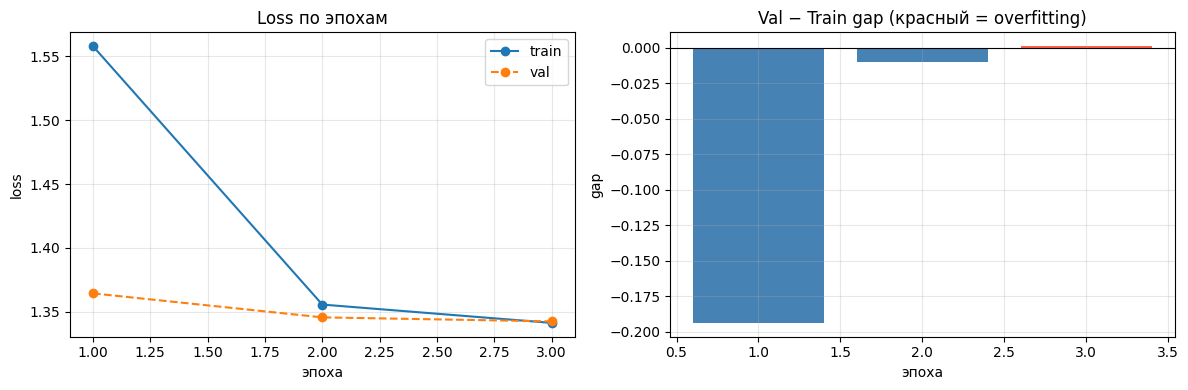

финальный gap: +0.0012


In [18]:
train_vals = [x["train"] for x in epoch_losses]
val_vals   = [x["val"]   for x in epoch_losses]
epochs     = range(1, len(epoch_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_vals, marker="o", label="train")
axes[0].plot(epochs, val_vals,   marker="o", label="val", linestyle="--")
axes[0].set_title("Loss по эпохам")
axes[0].set_xlabel("эпоха")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

gap = [v - t for t, v in zip(train_vals, val_vals)]
colors = ["tomato" if g > 0 else "steelblue" for g in gap]
axes[1].bar(epochs, gap, color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Val − Train gap (красный = overfitting)")
axes[1].set_xlabel("эпоха")
axes[1].set_ylabel("gap")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "distill_loss_curves.png", dpi=150)
plt.show()
print(f"финальный gap: {gap[-1]:+.4f}")

In [19]:
f = lambda x: f"{x:.4f}"

report_lines = [
    "# LLM Distillation Final Report", "",
    f"- Dataset : {DATASET_NAME}",
    f"- Teacher : {TEACHER_MODEL}",
    f"- Student : {STUDENT_MODEL}",
    f"- Teacher для дистилляции: {teacher_src}", "",
    "| Stage | EM | F1 | Latency (sec) | Throughput (samples/sec) | Max memory (GB) |",
    "|---|---:|---:|---:|---:|---:|",
    f"| P1 baseline teacher  | {f(p1.exact_match)} | {f(p1.f1)} | {f(p1.avg_latency_sec)} | {f(p1.throughput_samples_per_sec)} | {f(p1.max_memory_gb)} |",
    f"| P2 QLoRA teacher     | {f(p2.exact_match)} | {f(p2.f1)} | {f(p2.avg_latency_sec)} | {f(p2.throughput_samples_per_sec)} | {f(p2.max_memory_gb)} |",
    f"| P3 distilled student | {f(p3.exact_match)} | {f(p3.f1)} | {f(p3.avg_latency_sec)} | {f(p3.throughput_samples_per_sec)} | {f(p3.max_memory_gb)} |",
    "", f"Решение: {rationale}",]

report_text = "\n".join(report_lines) + "\n"
(ARTIFACTS_DIR / "final_report.md").write_text(report_text, encoding="utf-8")
save_manifest({"teacher_choice": teacher_src, "rationale": rationale})
print(report_text)

# LLM Distillation Final Report

- Dataset : rajpurkar/squad
- Teacher : microsoft/Phi-3-mini-4k-instruct
- Student : TinyLlama/TinyLlama-1.1B-Chat-v1.0
- Teacher для дистилляции: qlora

| Stage | EM | F1 | Latency (sec) | Throughput (samples/sec) | Max memory (GB) |
|---|---:|---:|---:|---:|---:|
| P1 baseline teacher  | 14.4531 | 43.0857 | 2.9673 | 0.3370 | 2.4306 |
| P2 QLoRA teacher     | 37.1094 | 58.5758 | 2.2483 | 0.4448 | 5.0936 |
| P3 distilled student | 55.4688 | 67.8043 | 0.9698 | 1.0312 | 5.3671 |

Решение: delta_f1=15.4901, threshold=0.0100



In [20]:
# анализ качества P3 по топикам SQuAD
import pandas as pd
from collections import defaultdict

preds_p3  = [json.loads(l) for l in
             (ARTIFACTS_DIR / "p3_predictions.jsonl").read_text().strip().split("\n")]
id_to_title = {str(row["id"]): row["title"] for row in test_raw}

topic_stats = defaultdict(lambda: {"correct": 0, "total": 0})
for p in preds_p3:
    title     = id_to_title.get(p["id"], "unknown")
    pred_norm = " ".join(p["pred"].lower().split())
    gold_norm = " ".join(p["gold"][0].lower().split()) if p["gold"] else ""
    topic_stats[title]["total"]   += 1
    if pred_norm == gold_norm:
        topic_stats[title]["correct"] += 1

rows = [{"topic": t, "em": s["correct"]/s["total"]*100, "n": s["total"]}
        for t, s in topic_stats.items()]
df = pd.DataFrame(rows).sort_values("em", ascending=False)
print(df.to_string(index=False))

                                    topic         em  n
                             Prime_number 100.000000  1
                       Fresno,_California 100.000000  5
                      Newcastle_upon_Tyne  80.000000  5
                                   Oxygen  75.000000  4
                            Super_Bowl_50  73.076923 26
                     Victoria_(Australia)  66.666667  3
                           Private_school  66.666667  6
                                 Islamism  66.666667  3
                                  Geology  66.666667  3
          Computational_complexity_theory  66.666667  3
                           Apollo_program  62.500000  8
                                  Teacher  57.142857  7
                              Chloroplast  50.000000  8
                                 Pharmacy  50.000000  4
                      Scottish_Parliament  50.000000  2
Intergovernmental_Panel_on_Climate_Change  50.000000  2
                       Harvard_University  50.00

In [21]:
# П4 — альтернативный teacher: модель уже дообученная на SQuAD
# сравниваем с нашим QLoRA чтобы понять стоило ли дообучать вообще

P4_MODEL  = "deepset/roberta-base-squad2"  # encoder модель, дообученная на SQuAD2
p4_path   = ARTIFACTS_DIR / "p4_squad_teacher_metrics.json"

if p4_path.exists() and not FORCE_RERUN:
    p4_payload = load_json(p4_path)
else:
    from transformers import pipeline

    # эта модель — extractive QA pipeline, не decoder
    # она возвращает span напрямую без генерации
    qa_pipeline = pipeline(
        "question-answering",
        model=P4_MODEL,
        device=0 if torch.cuda.is_available() else -1,
    )

    squad_metric = evaluate.load("squad")
    preds, refs, latencies = [], [], []

    for row in test_raw:
        t0  = time.perf_counter()
        out = qa_pipeline(question=row["question"], context=row["context"],
                          max_answer_len=MAX_NEW)
        latencies.append(time.perf_counter() - t0)

        pred    = out["answer"].strip()
        answers = row["answers"].get("text", [])
        starts  = row["answers"].get("answer_start", [0] * len(answers))

        rid = str(row["id"])
        preds.append({"id": rid, "prediction_text": pred})
        refs.append({"id": rid, "answers": {"text": answers, "answer_start": starts}})

    scores   = squad_metric.compute(predictions=preds, references=refs)
    avg_t    = sum(latencies) / max(1, len(latencies))
    tput     = len(latencies) / max(1e-9, sum(latencies))

    p4_payload = {
        "stage": "P4_squad_pretrained_teacher",
        "model": P4_MODEL,
        "dataset": DATASET_NAME,
        "metrics": {
            "exact_match": float(scores["exact_match"]),
            "f1":          float(scores["f1"]),
            "avg_latency_sec":          float(avg_t),
            "throughput_samples_per_sec": float(tput),
            "sample_count": len(preds),}
    }
    save_json(p4_path, p4_payload)

print(f"P4 EM: {p4_payload['metrics']['exact_match']:.2f}%")
print(f"P4 F1: {p4_payload['metrics']['f1']:.2f}%")
load_json(p4_path)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


P4 EM: 85.55%
P4 F1: 89.57%


{'stage': 'P4_squad_pretrained_teacher',
 'model': 'deepset/roberta-base-squad2',
 'dataset': 'rajpurkar/squad',
 'metrics': {'exact_match': 85.546875,
  'f1': 89.57287424289892,
  'avg_latency_sec': 0.01686114598044952,
  'throughput_samples_per_sec': 59.307949836831895,
  'sample_count': 256}}

In [22]:
f = lambda x: f"{x:.4f}"

p4m = p4_payload["metrics"]

report_lines = [
    "# LLM Distillation Final Report", "",
    f"- Dataset : {DATASET_NAME}",
    f"- Teacher : {TEACHER_MODEL}",
    f"- Student : {STUDENT_MODEL}",
    f"- Teacher для дистилляции: {teacher_src}", "",
    "| Stage | EM | F1 | Latency (sec) | Throughput (samples/sec) |",
    "|---|---:|---:|---:|---:|",
    f"| P1 baseline teacher  | {f(p1.exact_match)} | {f(p1.f1)} | {f(p1.avg_latency_sec)} | {f(p1.throughput_samples_per_sec)} |",
    f"| P2 QLoRA teacher     | {f(p2.exact_match)} | {f(p2.f1)} | {f(p2.avg_latency_sec)} | {f(p2.throughput_samples_per_sec)} |",
    f"| P3 distilled student | {f(p3.exact_match)} | {f(p3.f1)} | {f(p3.avg_latency_sec)} | {f(p3.throughput_samples_per_sec)} |",
    f"| P4 SQuAD pretrained  | {f(p4m['exact_match'])} | {f(p4m['f1'])} | {f(p4m['avg_latency_sec'])} | {f(p4m['throughput_samples_per_sec'])} |",
    "", f"Решение: {rationale}",
]

report_text = "\n".join(report_lines) + "\n"
(ARTIFACTS_DIR / "final_report.md").write_text(report_text, encoding="utf-8")
save_manifest({"teacher_choice": teacher_src, "rationale": rationale})
print(report_text)

# LLM Distillation Final Report

- Dataset : rajpurkar/squad
- Teacher : microsoft/Phi-3-mini-4k-instruct
- Student : TinyLlama/TinyLlama-1.1B-Chat-v1.0
- Teacher для дистилляции: qlora

| Stage | EM | F1 | Latency (sec) | Throughput (samples/sec) |
|---|---:|---:|---:|---:|
| P1 baseline teacher  | 14.4531 | 43.0857 | 2.9673 | 0.3370 |
| P2 QLoRA teacher     | 37.1094 | 58.5758 | 2.2483 | 0.4448 |
| P3 distilled student | 55.4688 | 67.8043 | 0.9698 | 1.0312 |
| P4 SQuAD pretrained  | 85.5469 | 89.5729 | 0.0169 | 59.3079 |

Решение: delta_f1=15.4901, threshold=0.0100



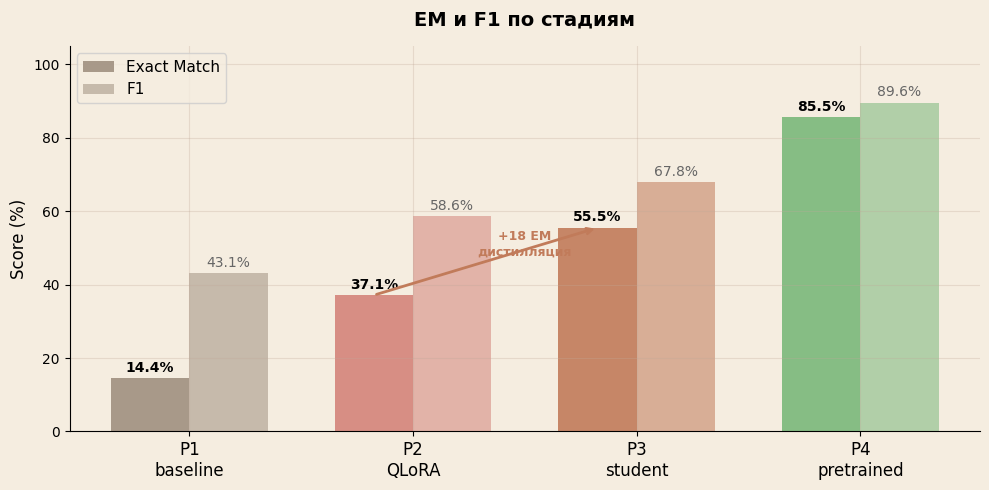

/tmp/ipykernel_58/2897259347.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stages, fontsize=12)


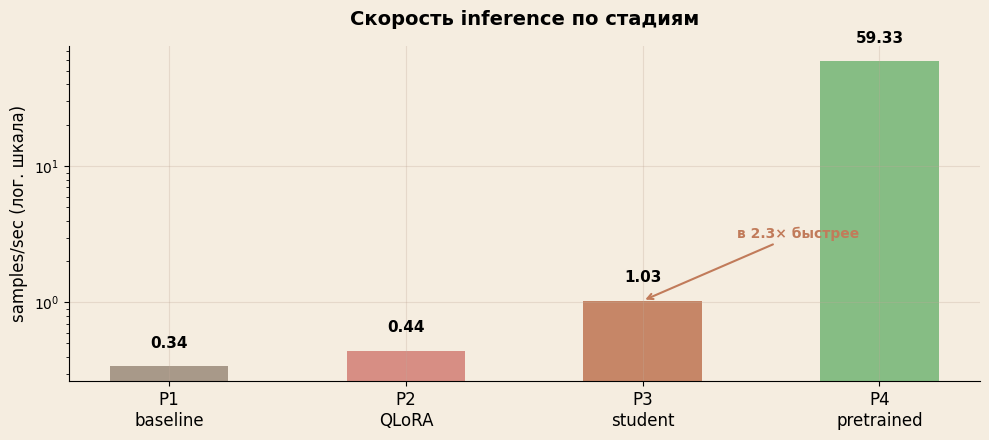

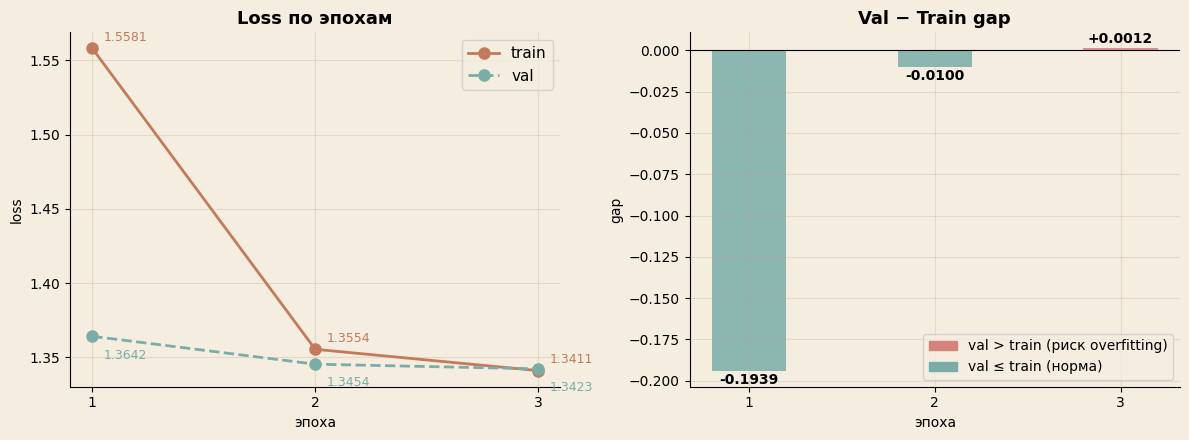

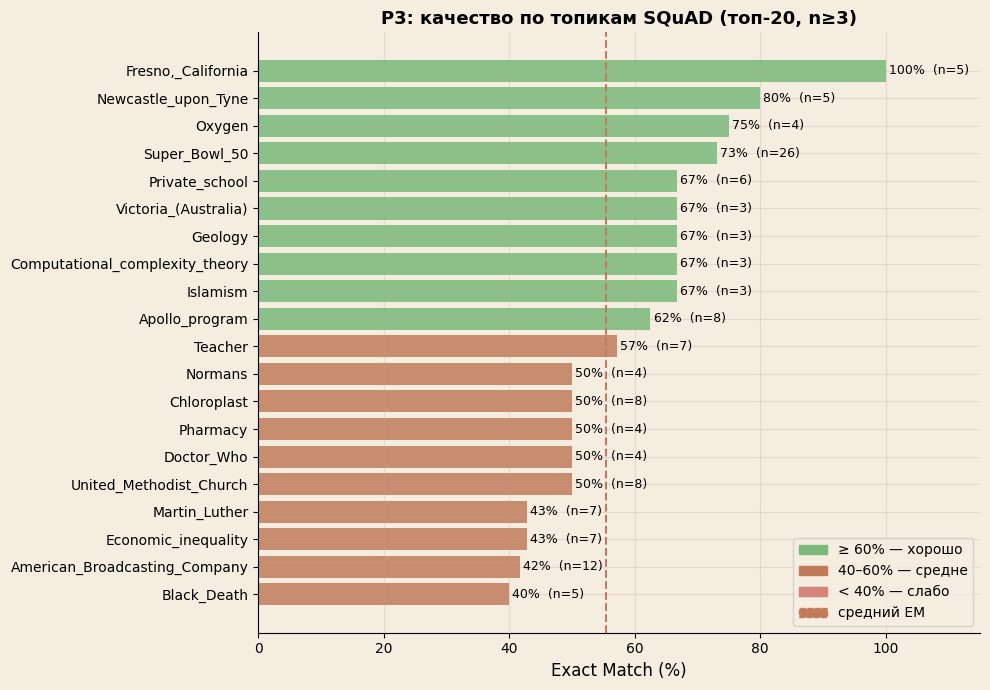

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── данные ────────────────────────────────────────────────────────────────────
stages    = ["P1\nbaseline", "P2\nQLoRA", "P3\nstudent", "P4\npretrained"]
em_vals   = [14.45, 37.11, 55.47, 85.55]
f1_vals   = [43.09, 58.58, 67.80, 89.57]
tput_vals = [0.34,  0.44,  1.03,  59.33]

BEIGE  = "#F5EDE0"
ROSE   = "#D4847A"
BROWN  = "#C17B5A"
TEAL   = "#7AADA8"
GREEN  = "#7AB87A"
MUTED  = "#A09080"
BAR_COLORS = [MUTED, ROSE, BROWN, GREEN]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.facecolor": BEIGE,
    "figure.facecolor": BEIGE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.color": "#C0A898",
})

# ── ГРАФИК 1: EM и F1 по стадиям ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(stages))
w = 0.35

bars_em = ax.bar(x - w/2, em_vals, w, label="Exact Match", color=BAR_COLORS, alpha=0.9)
bars_f1 = ax.bar(x + w/2, f1_vals, w, label="F1",          color=BAR_COLORS, alpha=0.55)

for bar in bars_em:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars_f1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10, color="#666")

ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("EM и F1 по стадиям", fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)

# стрелка P2→P3
ax.annotate("", xy=(2 - w/2, 55.47), xytext=(1 - w/2, 37.11),
            arrowprops=dict(arrowstyle="->", color=BROWN, lw=2))
ax.text(1.5, 48, "+18 EM\nдистилляция", ha="center", fontsize=9, color=BROWN, fontweight="bold")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "graph1_em_f1.png", dpi=150, bbox_inches="tight")
plt.show()

# ── ГРАФИК 2: Throughput (скорость) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

# P4 огромный — делаем лог шкалу
bars = ax.bar(stages, tput_vals, color=BAR_COLORS, alpha=0.9, width=0.5)
ax.set_yscale("log")

for bar, val in zip(bars, tput_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.3,
            f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("samples/sec (лог. шкала)", fontsize=12)
ax.set_title("Скорость inference по стадиям", fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(stages, fontsize=12)

# выделяем P3 vs P2
ax.annotate("в 2.3× быстрее", xy=(2, 1.03), xytext=(2.4, 3),
            arrowprops=dict(arrowstyle="->", color=BROWN, lw=1.5),
            fontsize=10, color=BROWN, fontweight="bold")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "graph2_throughput.png", dpi=150, bbox_inches="tight")
plt.show()

# ── ГРАФИК 3: Train / Val loss по эпохам ─────────────────────────────────────
# данные из нашего прогона
train_vals = [x["train"] for x in epoch_losses]
val_vals   = [x["val"]   for x in epoch_losses]
epochs     = list(range(1, len(epoch_losses) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# левый — кривые
axes[0].plot(epochs, train_vals, marker="o", color=BROWN, linewidth=2, label="train", markersize=8)
axes[0].plot(epochs, val_vals,   marker="o", color=TEAL,  linewidth=2, label="val",   markersize=8, linestyle="--")
for i, (t, v) in enumerate(zip(train_vals, val_vals)):
    axes[0].text(epochs[i] + 0.05, t + 0.005, f"{t:.4f}", fontsize=9, color=BROWN)
    axes[0].text(epochs[i] + 0.05, v - 0.015, f"{v:.4f}", fontsize=9, color=TEAL)
axes[0].set_title("Loss по эпохам", fontsize=13, fontweight="bold")
axes[0].set_xlabel("эпоха")
axes[0].set_ylabel("loss")
axes[0].legend(fontsize=11)
axes[0].set_xticks(epochs)

# правый — gap
gap    = [v - t for t, v in zip(train_vals, val_vals)]
colors = [ROSE if g > 0 else TEAL for g in gap]
axes[1].bar(epochs, gap, color=colors, alpha=0.85, width=0.4)
axes[1].axhline(0, color="black", linewidth=0.8)
for i, g in enumerate(gap):
    axes[1].text(epochs[i], g + (0.003 if g >= 0 else -0.008),
                 f"{g:+.4f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Val − Train gap", fontsize=13, fontweight="bold")
axes[1].set_xlabel("эпоха")
axes[1].set_ylabel("gap")
axes[1].set_xticks(epochs)

rose_patch = mpatches.Patch(color=ROSE, label="val > train (риск overfitting)")
teal_patch = mpatches.Patch(color=TEAL, label="val ≤ train (норма)")
axes[1].legend(handles=[rose_patch, teal_patch], fontsize=10)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "graph3_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── ГРАФИК 4: анализ по топикам ───────────────────────────────────────────────
# запускать после cell 20 (анализ топиков)
if 'df' in dir():
    df_plot = df[df["n"] >= 3].sort_values("em", ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_topics = [GREEN if v >= 60 else BROWN if v >= 40 else ROSE for v in df_plot["em"]]
    bars = ax.barh(df_plot["topic"], df_plot["em"], color=colors_topics, alpha=0.85)

    for bar, n in zip(bars, df_plot["n"]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.0f}%  (n={n})", va="center", fontsize=9)

    ax.set_xlabel("Exact Match (%)", fontsize=12)
    ax.set_title("P3: качество по топикам SQuAD (топ-20, n≥3)", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 115)
    ax.axvline(55.47, color=BROWN, linestyle="--", linewidth=1.5, label=f"средний EM: 55.5%")
    ax.legend(fontsize=11)

    green_p = mpatches.Patch(color=GREEN, label="≥ 60% — хорошо")
    brown_p = mpatches.Patch(color=BROWN, label="40–60% — средне")
    rose_p  = mpatches.Patch(color=ROSE,  label="< 40% — слабо")
    ax.legend(handles=[green_p, brown_p, rose_p, 
               mpatches.Patch(color=BROWN, linestyle="--", label="средний EM")], fontsize=10)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "graph4_topics.png", dpi=150, bbox_inches="tight")
    plt.show()

In [25]:
# примеры предсказаний P1 / P3 
import random

preds_p1 = [json.loads(l) for l in
            (ARTIFACTS_DIR / "p1_predictions.jsonl").read_text().strip().split("\n")]
preds_p3 = [json.loads(l) for l in
            (ARTIFACTS_DIR / "p3_predictions.jsonl").read_text().strip().split("\n")]

id_to_p1 = {p["id"]: p for p in preds_p1}

print("=" * 70)
print("ПРИМЕРЫ: P1 vs P3")
print("=" * 70)

# берём 4 интересных случая
shown = 0
for p3 in preds_p3:
    if shown >= 4:
        break
    p1 = id_to_p1.get(p3["id"])
    if not p1:
        continue
    gold = p3["gold"][0] if p3["gold"] else ""
    p1_pred = p1["pred"]
    p3_pred = p3["pred"]

    # берём только случаи где P3 правильно а P1 нет
    if p3_pred.lower() == gold.lower() and p1_pred.lower() != gold.lower():
        print(f"Вопрос : {p3['question']}")
        print(f"Правильный ответ: {gold}")
        print(f"P1 ответил: {p1_pred}")
        print(f"P3 ответил: {p3_pred}  ✓")
        print("-" * 70)
        shown += 1

ПРИМЕРЫ: P1 vs P3
Вопрос : In what year did Massachusetts first require children to be educated in schools?
Правильный ответ: 1852
P1 ответил: Massachusetts first required children to be educated in schools in 1852.
P3 ответил: 1852  ✓
----------------------------------------------------------------------
Вопрос : When were stromules discovered?
Правильный ответ: 1962
P1 ответил: Stromules were first observed in 1962.
P3 ответил: 1962  ✓
----------------------------------------------------------------------
Вопрос : Who got a touchdown making the score 10-7?
Правильный ответ: Jonathan Stewart
P1 ответил: Jonathan Stewart finished the drive with a 1-yard touchdown run.
P3 ответил: Jonathan Stewart  ✓
----------------------------------------------------------------------
Вопрос : How many Examination Boards exist in India?
Правильный ответ: 30
P1 ответил: 30 different Examination Boards or academic authorities exist in India.
P3 ответил: 30  ✓
--------------------------------------------